In [6]:
#load relevant packages

import pandas as pd
import ast
import pysam
from Bio import SeqIO
import glob
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from histogramplotter import *
import os
from dnds import dnds, pnps
import scipy.stats as stats
from scipy.stats import shapiro
# print(dnds.__file__)

from utils_nd import *
import argparse

In [24]:
# set up directories to which to point

experiment_id = 'jh_008' # user sets this
min_contexts = 20 # sets desired minimum contexts to be included in graphing

if experiment_id == 'jh_005':
    fasta_name = 'pjh3_nbonly'
    library_top_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/*'
    score_tag_name = 'lib'
elif experiment_id == 'jh_004':
    fasta_name = 'pmaa23_nbonly'
    library_top_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'rep1_x'
elif experiment_id == 'jh_006':
    fasta_name = 'pjh3_nbonly'
    library_top_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'rep1_x'
elif experiment_id == 'jh_007':
    fasta_name = 'pmaa23_nbonly'
    library_top_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'rep1'
    score_tag_name2 = 'rep2'
elif experiment_id == 'jh_008':
    fasta_name = 'pmaa23_nbonly'
    library_top_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/'
    score_tag_name = 'rep1'
    score_tag_name2 = 'rep2'
    score_tag_name3 = 'rep3'

csv_files = glob.glob(os.path.join(library_top_df_paths, f"*scores*.csv"))
print(csv_files)

['../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_008/neutral_drift_library/library_scores_jh_008.csv']


reference sequence: QVQLVESGGGLVQPGGSLRLSCAASGGNVSMLSLGWFRQAPGQGLEAVAAIDYEGKTYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASVVGSLARNWYTYWGQGTLVTVS
wild type score: 0.1694723478873004


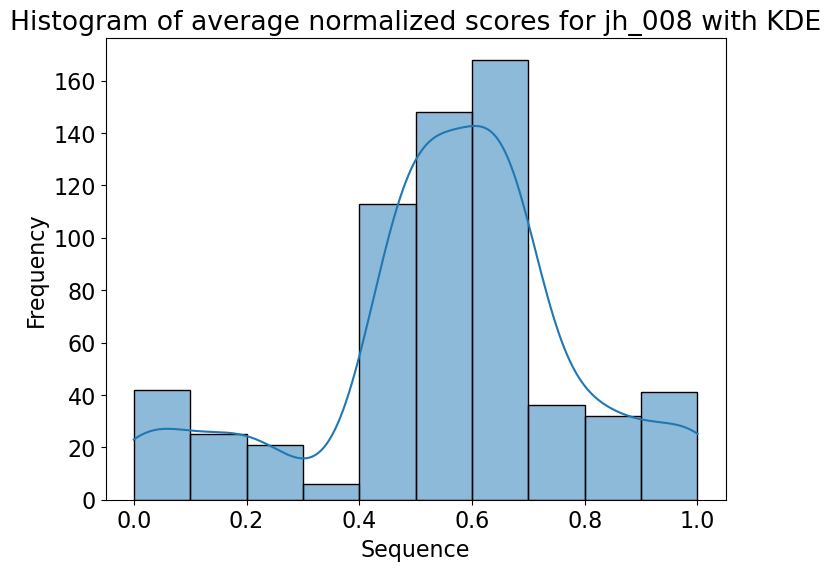

Shapiro-Wilk p-value: 0.0000
Probably not normal


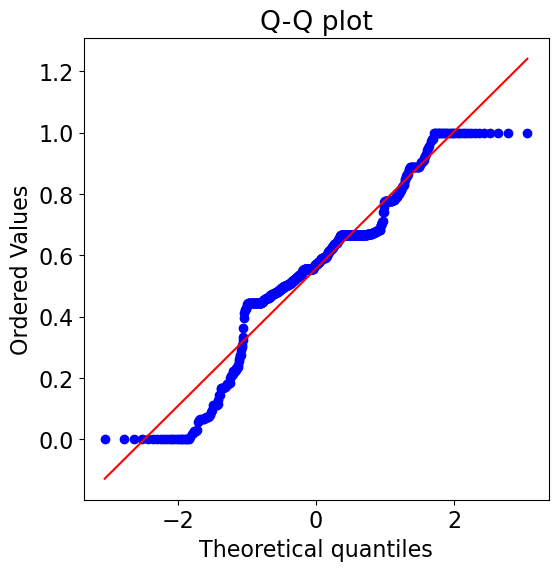

count    632.000000
mean       0.556735
std        0.229835
min        0.000000
25%        0.465326
50%        0.572643
75%        0.666667
max        1.000000
Name: average normalized score, dtype: float64
                                           aa_sequence  \
591  QVQLVESGGGLAQPGGSLRLSCAASGGNVSMLSLGWFRQAPGQGLE...   
602  QVQLVESGGGLMQPGGSLRLSCAASGGNVSMLSLGWFRQAPGQGLE...   
615  QVQLVESGGGLVQPGGSLRLSCAASGGNVSMLSLGWFRQAPGQGLE...   
617  QVQLVESGGGLVQPGGSLRLSCAASGGNVSMLSLGWFRQAPGQGLE...   
620  QVQLVESGGGLVQPGGSLRLSCAASGGNVSMLSLGWFRQAPGQGLE...   

                                          dna_sequence  \
591  ['CAGGTCCAACTGGTCGAGAGCGGTGGGGGACTGGCGCAGCCAGG...   
602  ['CAGGTCCAACTGGTCGAGAGCGGTGGGGGACTGATGCAGCCAGG...   
615  ['CAGGTCCAACTGGTCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...   
617  ['CAGGTCCAACTGGTCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...   
620  ['CAGGTCCAACTGGTCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...   

                           dna_mutations aa_mutations number_dna_mutations  \
591              

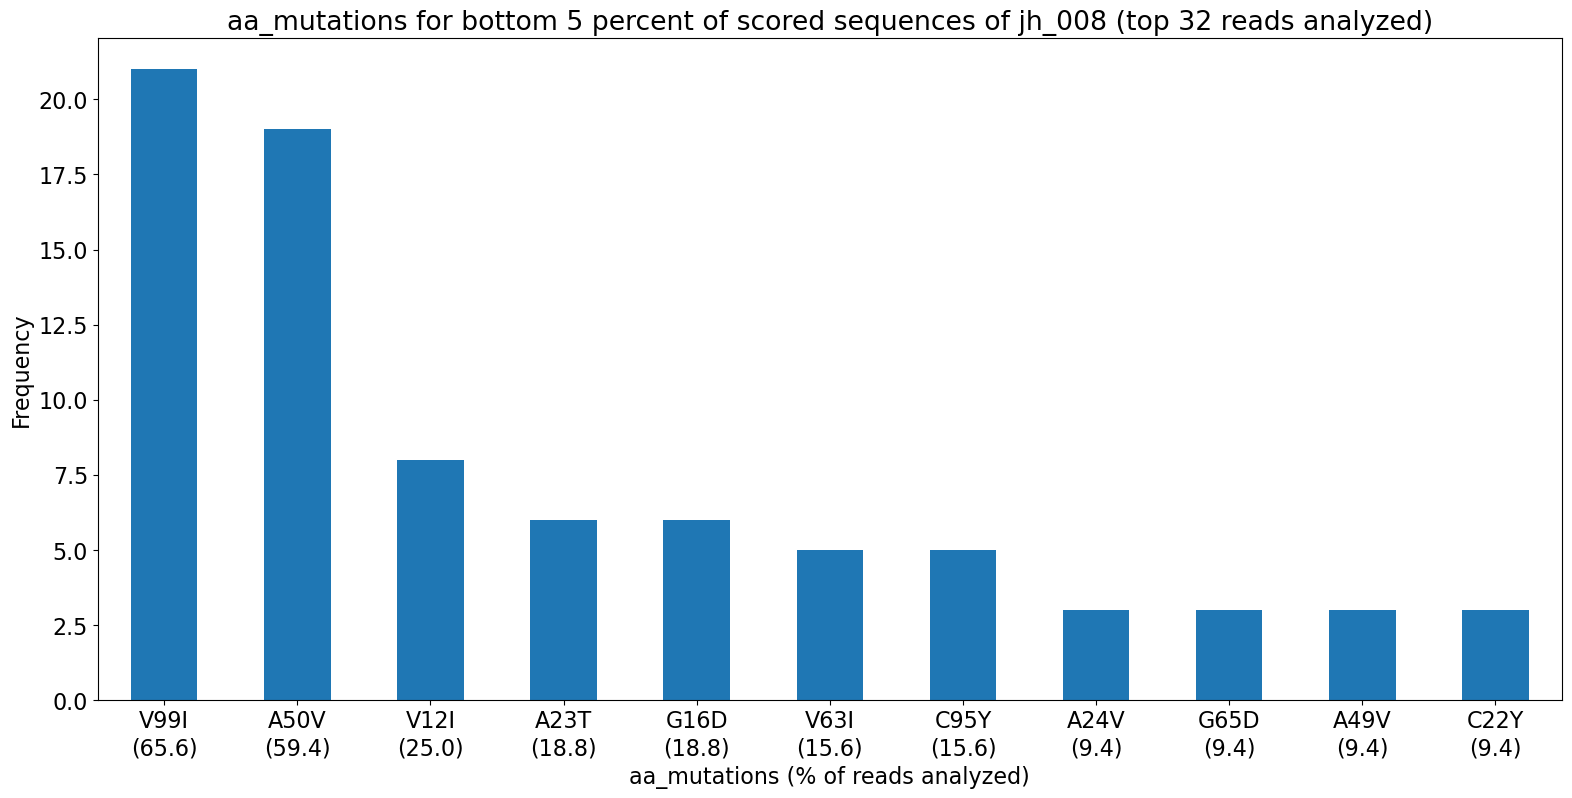

Histogram saved as ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_008/neutral_drift_library/plots/bottom5_muts_9pct.png


In [26]:
# let's learn some more about the best binders and what is common or different among them
for library_path in csv_files:
    # import and loading
    if experiment_id == 'jh_005':
        library_type = library_path.split('/')[-2]
        library_name = library_path.split('/')[-2] + '_' + experiment_id
        print(library_name)
    else:
        library_name = library_path.split('/')[-1]
    library_df = pd.read_csv(library_path, index_col=0)

    # reference specifications
    ref_fasta_path = f'../../minibinders_orthorep_data/ngs_raw/{experiment_id}/references/{fasta_name}.fasta'
    ref_fasta = SeqIO.read(ref_fasta_path, "fasta")
    parent_dna_seq = ref_fasta.seq
    parent_dna_id = ref_fasta.id
    
    parent_aa_seq = translate_sequence(parent_dna_seq)
    
    print(f"reference sequence: {parent_aa_seq}")

    # capture wild type score from dataframe
    
    try:
        wt_slice = library_df[library_df['aa_sequence'] == parent_aa_seq]
        # print(wt_slice)
        if wt_slice.empty:
            print("no wild type score found, using previous WT score")
        else:
            # print(wt_slice)
            if experiment_id == 'jh_007':
                wt_score = np.mean([wt_slice[f'normalized_score_{score_tag_name}'].values[0], wt_slice[f'normalized_score_{score_tag_name2}'].values[0]])
            elif experiment_id == 'jh_008':
                # wt_scores_reps = [wt_slice[f'normalized_score_{score_tag_name}'].values[0], wt_slice[f'normalized_score_{score_tag_name2}'].values[0]]
                wt_score = np.mean([wt_slice[f'normalized_score_{score_tag_name}'].values[0],
                                    wt_slice[f'normalized_score_{score_tag_name2}'].values[0],
                                    wt_slice[f'normalized_score_{score_tag_name3}'].values[0]])
            else:
                wt_score = wt_slice[f'normalized_score_{score_tag_name}'].values[0]
            print(f"wild type score: {wt_score}")
    except Exception as e:
        print(f"error: {e}")

    # obtain averages and err for replicate scores
    
    if experiment_id == 'jh_007':
        library_df['average normalized score'] = library_df[[f'normalized_score_{score_tag_name}', f'normalized_score_{score_tag_name2}']].mean(axis=1)
        print(library_df['average normalized score'][:5])
        library_df['normalized score error'] = library_df[[f'normalized_score_{score_tag_name}', f'normalized_score_{score_tag_name2}']].std(axis=1)

        
        library_org_df = library_df.sort_values(by=['number_aa_mutations',
                                                    'average normalized score',
                                                    'normalized score error'])
    elif experiment_id == 'jh_008':
        library_df['average normalized score'] = library_df[[f'normalized_score_{score_tag_name}', f'normalized_score_{score_tag_name2}', f'normalized_score_{score_tag_name3}']].mean(axis=1)
        # print(library_df['average normalized score'][:5])

        library_df['normalized score error'] = library_df[[f'normalized_score_{score_tag_name}', f'normalized_score_{score_tag_name2}', f'normalized_score_{score_tag_name3}']].std(axis=1)
        # print(library_df['normalized score error'][:5])
        
        library_org_df = library_df.sort_values(by=['number_aa_mutations',
                                                    'average normalized score',
                                                    'normalized score error'])
    
    # plot as a histogram to see if there is some normalness (and get some stats)

    plt.figure(figsize=(8,6))
    sns.histplot(library_org_df['average normalized score'], bins=10, kde=True)
    plt.title(f'Histogram of average normalized scores for {experiment_id} with KDE')
    plt.xlabel('Sequence')
    plt.ylabel('Frequency')
    plt.show()

    stat, p = shapiro(library_org_df['average normalized score'])
    print(f'Shapiro-Wilk p-value: {p:.4f}')
    if p > 0.05:
        print("Probably normal")
    else:
        print("Probably not normal")

    plt.figure(figsize=(6, 6))
    stats.probplot(library_org_df['average normalized score'], dist="norm", plot=plt)
    plt.title('Q-Q plot')
    plt.show()

    print(library_org_df['average normalized score'].describe())
    library_center = library_org_df['average normalized score'].median() 

    # take the top 11 percent
    desired_quant = 0.05

    library_top_df = library_org_df[library_org_df['average normalized score'] <= library_org_df['average normalized score'].quantile(desired_quant)]
    print(library_top_df[:5])

    library_top_df.sort_values(by=['number_aa_mutations',
                                   'average normalized score',
                                   'normalized score error'])
    print(len(library_top_df))

    # next we shall count the various mutations and plot as character bars (like old script _04)

    num_sequences = len(library_top_df)
    print(f"{num_sequences} unique sequences (unweighted)")
    # isolate column of AA mutations only
    aa_mut_df = library_top_df['aa_mutations']
    # print(aa_mut_df[0])
    # print(type(aa_mut_df))
    aa_mut_df = aa_mut_df.apply(ast.literal_eval)
    # print(aa_mut_df[:5])
    aa_mut_flat = [item for sublist in aa_mut_df for item in sublist]
    # print(aa_mut_flat[:10])
    total_aa_muts = len(aa_mut_flat)
    # print(total_aa_muts)
    aa_mut_flat_df = pd.DataFrame(aa_mut_flat, columns = ['aa_mutations'])
    # print(aa_mut_flat_df[:6])
    # print(type(aa_mut_flat_df))


    
    # mutations weighted by read count
    # aa_mut_df_weights = library_top_df[['read_count','aa_mutations']].copy()
    # # print(type(aa_mut_df_weights))
    # num_weighted_reads = library_top_df['read_count'].sum()
    # print(f"{num_weighted_reads} total reads (weighted)")

    
    # aa_mut_weights_explode_df = pd.DataFrame(library_top_df['aa_mutations'].repeat(library_top_df['read_count']))
    # # print(aa_mut_weights_explode_df[:8])
    # aa_mut_weights_explode = aa_mut_weights_explode_df['aa_mutations'].reset_index(drop=True)
    # print(aa_mut_weights_explode[:9])
    # print(aa_mut_weights_explode[1000:1010])

    # aa_mut_weights_explode_ser = aa_mut_weights_explode.squeeze()

    # aa_mut_weights_explode = aa_mut_weights_explode.apply(ast.literal_eval)
    # # print(aa_mut_weights_explode[:10])
    # aa_mut_weight_flat = [item2 for sublist2 in aa_mut_weights_explode for item2 in sublist2]
    # # print(aa_mut_weight_flat[:14])
    # # print(aa_mut_weight_flat[1000:1009])
    # aa_mut_weight_flat_df = pd.DataFrame(aa_mut_weight_flat, columns = ['aa_mutations'])
    # print(aa_mut_weight_flat_df[:8])



   
    # csv_outputaa_path = f'../Mutation_Finder_Miguel_Updated_16JAN/minibinders_data/minibinders_outputs/{experiment_id}/library_top_dfs/{sample_name}_mutation_readct{read_ct}_aaseq.csv'
    top_csv_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/top{int((1-desired_quant)*100)}_nd_library.csv'
    bot_csv_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/bottom{int(desired_quant*100)}_nd_library.csv'
    library_top_df.index = ['k' + str(idx) for idx in library_top_df.index]
    library_top_df.to_csv(bot_csv_outpath)

    # aa_seq_weights_explode_df = pd.DataFrame(library_top_df['aa_sequence'].repeat(library_top_df['read_count']))

    # # csv_weighted_outputaa_path = f'../Mutation_Finder_Miguel_Updated_16JAN/minibinders_data/minibinders_outputs/{experiment_id}/library_top_dfs/{sample_name}_mutation_readct{read_ct}_weighted_aaseq.csv'
    # aa_seq_weights_explode_df.index = ['w' + str(idx) for idx in aa_seq_weights_explode_df.index]
    # aa_seq_weights_explode_df.to_csv(csv_weighted_outputaa_path)

    # # csv_outputdna_path = f'../Mutation_Finder_Miguel_Updated_16JAN/minibinders_data/minibinders_outputs/{experiment_id}/library_top_dfs/{sample_name}_mutation_readct{read_ct}_dnaseq.csv'
    # # library_top_df.index = ['j' + str(idx) for idx in library_top_df.index]
    # library_top_df['dna_sequence'].to_csv(csv_outputdna_path)

    # dna_seq_weights_explode_df = pd.DataFrame(library_top_df['dna_sequence'].repeat(library_top_df['read_count']))

    # # csv_weighted_outputdna_path = f'../Mutation_Finder_Miguel_Updated_16JAN/minibinders_data/minibinders_outputs/{experiment_id}/library_top_dfs/{sample_name}_mutation_readct{read_ct}_weighted_dnaseq.csv'
    # dna_seq_weights_explode_df.index = ['x' + str(idx) for idx in dna_seq_weights_explode_df.index]
    # # dna_seq_weights_explode_df.to_csv(csv_weighted_outputdna_path)

    pct_cut = 9
    charbars_output_path = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/bottom{int(desired_quant*100)}_muts_{pct_cut}pct.png'
    # charbars_output_path_weighted = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/top{(1-desired_quant)*100}_topmuts_weighted_{pct_cut}pct.png'
    freq_cutoff = (num_sequences*(pct_cut/100))
    # freq_cutoff_weighted = (num_weighted_reads*(pct_cut/100))
    sample_name = f'bottom {int(desired_quant*100)} percent of scored sequences of {experiment_id}'
    char_hist_unweighted = character_bars(aa_mut_flat_df, charbars_output_path, freq_cutoff, sample_name, num_sequences)
    # char_hist_weighted = character_bars(aa_mut_weight_flat_df, output_path_weighted, freq_cutoff_weighted, sample_name, num_weighted_reads)
